Gradient boosting (GBoost) is a powerful ensemble machine learning algorithm.
It generates a prediction model that evolves weak prediction models (i.e decision trees).
The weak prediction models added one at a time to the prediction model and fit to correct the prediction errors made by prior models. 
This is a type of ensemble machine learning model referred to as boosting.
Models are fit using any arbitrary differentiable loss function and gradient descent optimization algorithm. 
This gives the technique its name, “gradient boosting,” as the loss gradient is minimized as the model is fit, much like a neural network.
This approach makes the GBoost one of the most powerful techniques for building predictive models for classification or regression problems.


Extreme Gradient Boosting (XGBoost) is an efficient implementation of the gradient boosting algorithm.
It is built on the principles of gradient boosting framework and designed to "push the extreme of the computation limits of machines to provide a scalable, portable and accurate library."
Its efficient performance makes the algorithm one of the main algorithms used in winning solutions to machine learning competitions, like those on Kaggle.


This investigation applies the GBoost and the XGBoost algorithms for a safety problem.
The GBoost and the XGBoost algorithms are applied to find important features that are critical in safety prediction thought both classification and regression approaches.
Thus, the investigation is sepeared into two sections for the classification and the regression problem.
In each section, five mainstream implementations of the GBoost and the XGBoost are applied to build prediction model with feature importances.
The five implemetation are:

- GBoost Algorithm
    - Scikit-Learn Gradient Boosting Approach
        - GradientBoostingClassifier
        - GradientBoostingRegressor
    - Scikit-Learn Histogram-based Gradient Boosting Approach
        - HistGradientBoostingClassifier
        - HistGradientBoostingRegressor
 
- XGBoost Algorithm
    - XGBoost 
        - XGBClassifier
        - XGBRFRegressor
    - LightGBM
        - LGBMClassifier
        - LGBMRegressor
    - Catboost
        - CatBoostClassifier
        - CatBoostRegressor
    - H2O 

To provide an investigation as exhaustive as possible, H2O is also mentioned here as another major XGBoost implementation.
As its high-performance on GPU, H2O worthes a try in the future, although its install requirements are beyond the reach of this investigation.



The implementations of the XGBoost Algorithm also introduce a hyperparameter-tuning process for parameter optimization.
The implementations of XGBoost, LightGBM and Catboost have different hyperparameters.
Thus, various subsets of these hyperparameters are selected for the tuning.
As the project may face a complex dataset, an elaboratedhyperparameter-tuning process will be necessary for the future.

The first section applies the GBoost and the XGBoost algorithms for classification problem.
After training default models and optimised models, various feature importance are generated.
The rankings of feature importance for the classification problem are summarised in the following table.

In [1]:
# Put the "Feature_importance_ranking_classifiers.csv" file in the "result" directory. Or run this cell after this ipynb file reaches the summary of first section.
import pandas as pd

read_rank_classifiers = pd.read_csv('result/Feature_importance_ranking_classifiers.csv', index_col="Features")
read_rank_classifiers

FileNotFoundError: [Errno 2] No such file or directory: 'result/Feature_importance_ranking_classifiers.csv'

The second section also applies the GBoost and the XGBoost algorithms for regression problem.
After training default models and optimised models, various feature importance are generated.
The rankings of feature importance for the regression problem are summarised in the following table.

In [199]:
# Put the "Feature_importance_ranking_regressor.csv" file in the "result" directory. Or run this cell after this ipynb file reaches the summary of second section.
read_rank_regressor = pd.read_csv('result/Feature_importance_ranking_regressor.csv', index_col="Features")
read_rank_regressor

,GradientBoosting,XGBoost (Optimised),CatBoost (Optimised)
Features,,,
Rolling12DelayedActionCnt,1,1.0,1
DelayedPerEmp,2,NaN,2
AvgReqDays,3,3.0,9
NM_Rolling12NMCount,4,5.0,6
AvgActualDays,5,6.0,5
AvgDelayedDays,6,2.0,8
MinActualDays,7,NaN,7
MinReqDays,8,NaN,11
MaxDelayedDays,9,NaN,3


# Library Preparation

This investigation requires these libraries: sklearn, xgboost, lightbgm, and catboost.

The current version of sklearn is 0.23.2.

In [193]:
import sklearn
print(sklearn.__version__)

0.23.2


The current version of xgboost is 1.3.1.

In [195]:
import xgboost
print(xgboost.__version__)

1.3.1


Run this line to install the xgboost library.

In [ ]:
#! pip install xgboost

The current version of lightgbm is 3.1.1.

In [196]:
import lightgbm
print(lightgbm.__version__)

3.1.1


Run this line to install the lightgbm library.

In [ ]:
#!conda install -c conda-forge lightgbm

The current version of lightgbm is 0.24.4.

In [197]:
import catboost
print(catboost.__version__)

0.24.4


Run this line to install the catboost library.

In [ ]:
# conda install -c conda-forge catboost

# Section 1: Classification

The first section applies the GBoost and the XGBoost algorithms for classification problem.

## Data Preprocessing

### Import Libraries

In [3]:
import numpy as np
import pandas as pd
from time import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scipy import stats

###  Import Dataset

In [4]:
#import dataset
data = pd.read_csv('dataset/impact.csv')
# split the traing and testing datasets
X = data.drop('TRIFR',1)
y = data['TRIFR']

### Transforms 'Y' value into labels for classificaiton

Transforms 'TRIFR' value into label for the classification problem. Set the threshold at the 35% distribution of the 'TRIFR' value.

In [5]:
threshold = np.sort(y)[int(np.ceil(len(y)* 0.35))]
threshold

4.787116911

Label "0" if the value is lower or equal to this threshold, otherwise label "1".

In [6]:
y= np.where(y<=threshold, 0, 1) 

### Skew "X" values

For normally distributed data, the skewness of the data should be about 0. 
A skewness value > 0 means that there is more weight in the left tail of the distribution, and vice versa for a skewness value < 0.
The log method can be applied to decrease the skewness of the data, which should be positive values.
In this case, columns of ``AvgDelayedDays`` and ``MinDelayedDays`` are selected to correct their skewness.
The skewness value of ``AvgDelayedDays`` decreases from 2.19824437 to 1.57089682.
Yet the skewness value of ``MinDelayedDays`` remains the same (3.47439614) because it is a high bias data.
Only one instance has a value of 2 in this feature/attribute, while the rest have another value of 1.
This extreme case shows the effect of bias data on its skewness value. 

transform features with skewness > 1 or skewness < -1 

In [7]:
import copy
X_skewed = copy.deepcopy(X)
for col in range(X_skewed.shape[1]):
    if stats.mstats.skew(X_skewed.iloc[:, col]).data >1 or stats.mstats.skew(X_skewed.iloc[:, col]).data < -1 :
        if len(X_skewed[X_skewed.iloc[:, col]>0]) < X_skewed.shape[0]:
            # to shew, each value in the column should be positive number
            pass
        else:
            X_skewed.iloc[:, col] = np.log(X_skewed.iloc[:, col])
    else:
        pass

In [8]:
stats.mstats.skew(X).data

array([-0.35461034, -0.32561725,  2.19824437,  3.47439614,  0.05099458,
        0.03762476,  0.16789008, -0.92026225, -0.57649107, -0.407614  ,
       -0.60945159,  0.77786451, -0.64815153,  0.46823692,  1.79700391])

In [9]:
stats.mstats.skew(X_skewed).data

array([-0.35461034, -0.32561725,  1.57089682,  3.47439614,  0.05099458,
        0.03762476,  0.16789008, -0.92026225, -0.57649107, -0.407614  ,
       -0.60945159,  0.77786451, -0.64815153,  0.46823692,  1.79700391])

In [10]:
X

,Rolling12DelayedActionCnt,DelayedPerEmp,AvgDelayedDays,MinDelayedDays,MaxDelayedDays,AvgReqDays,MinReqDays,MaxReqDays,AvgActualDays,MinActualDays,MaxActualDays,NM_MonthlyCount,NM_Rolling12NMCount,TrainingCount5Years,AuditCount5Years
0,132,0.61,65,1,699,146,-699,619,212,-52,708,2,12,0,0
1,92,0.42,78,1,528,78,-528,577,156,0,581,1,31,5,9
2,90,0.41,81,1,528,66,-528,577,148,0,581,3,33,3,0
3,89,0.41,82,1,528,58,-528,371,141,0,428,4,35,0,0
4,132,0.61,65,1,699,146,-699,619,211,-52,708,1,20,0,0
5,131,0.60,65,1,699,153,-699,619,218,-52,708,2,22,3,11
6,134,0.62,64,1,699,157,-699,619,222,-52,708,2,24,1,0
7,134,0.62,62,1,699,161,-699,619,223,-52,708,4,27,3,0
8,117,0.54,59,1,457,170,-204,577,230,-52,708,2,27,2,4
9,118,0.54,91,1,528,106,-528,577,198,0,581,6,31,3,12


In [11]:
X_skewed

,Rolling12DelayedActionCnt,DelayedPerEmp,AvgDelayedDays,MinDelayedDays,MaxDelayedDays,AvgReqDays,MinReqDays,MaxReqDays,AvgActualDays,MinActualDays,MaxActualDays,NM_MonthlyCount,NM_Rolling12NMCount,TrainingCount5Years,AuditCount5Years
0,132,0.61,4.174387,0.000000,699,146,-699,619,212,-52,708,2,12,0,0
1,92,0.42,4.356709,0.000000,528,78,-528,577,156,0,581,1,31,5,9
2,90,0.41,4.394449,0.000000,528,66,-528,577,148,0,581,3,33,3,0
3,89,0.41,4.406719,0.000000,528,58,-528,371,141,0,428,4,35,0,0
4,132,0.61,4.174387,0.000000,699,146,-699,619,211,-52,708,1,20,0,0
5,131,0.60,4.174387,0.000000,699,153,-699,619,218,-52,708,2,22,3,11
6,134,0.62,4.158883,0.000000,699,157,-699,619,222,-52,708,2,24,1,0
7,134,0.62,4.127134,0.000000,699,161,-699,619,223,-52,708,4,27,3,0
8,117,0.54,4.077537,0.000000,457,170,-204,577,230,-52,708,2,27,2,4
9,118,0.54,4.510860,0.000000,528,106,-528,577,198,0,581,6,31,3,12


In [12]:
X = X_skewed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
#keep record for comparison
accuracy = {}
speed = {}

## GBoost: Scikit-Learn Gradient Boosting Approach

This part applies GradientBoostingClassifier from the Scikit-Learn package for the classification problem.

### Import Libraries

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

### Import Model

In [15]:
model = GradientBoostingClassifier()

### Cross-validation

Cross-validation is conduected here to test the average performance of the default model on the dataset.
The average of score and time consumption in the iterations of cross-validation are record for a comparison with other implementations.


In [16]:
start = time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1)

speed["GradientBoosting"] = np.round(time() - start, 3)
accuracy["GradientBoosting"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['GradientBoosting']}\nStd: {np.std(score):.3f}\nRun time: {speed['GradientBoosting']}s"
)

Mean Accuracy: 0.633
Std: 0.257
Run time: 7.093s


##### It argues that this dataset is extremely small, so n_splits is set to 5 and n_repeats is 50 for a robust result for a model with default parameters.
The score values of these 50 repeats and their high variance (see below) can support this argument.
Some reaches 100% accuracy while others just reach 33%.
To decrease this variance, a dataset with a decent amount of the instance will be helpful.
In addition, optimization of the model's parameters will also lead to a better, more consistent results of cross-validation.


In [17]:
score

array([0.33333333, 0.66666667, 1.        , 0.33333333, 0.66666667,
       0.66666667, 0.33333333, 0.66666667, 0.66666667, 1.        ,
       0.66666667, 0.33333333, 1.        , 0.33333333, 0.66666667,
       0.33333333, 1.        , 1.        , 0.33333333, 0.33333333,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.33333333,
       0.33333333, 0.66666667, 1.        , 1.        , 0.66666667,
       0.33333333, 0.66666667, 1.        , 0.66666667, 1.        ,
       0.66666667, 0.        , 1.        , 0.33333333, 0.33333333,
       0.66666667, 1.        , 0.66666667, 0.33333333, 0.33333333,
       0.66666667, 0.66666667, 1.        , 0.66666667, 0.33333333,
       1.        , 1.        , 0.66666667, 0.66666667, 0.33333333,
       0.33333333, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       1.        , 0.33333333, 1.        , 0.33333333, 0.66666667,
       0.66666667, 1.        , 1.        , 0.        , 0.33333333,
       0.66666667, 0.66666667, 0.33333333, 0.66666667, 0.66666

### Fit The Model

In [18]:
# fit the model on the whole dataset
model.fit(X, y)

GradientBoostingClassifier()

### Plot Feature Importance

In [19]:
print("The impurity-based feature importances :\n", model.feature_importances_)

The impurity-based feature importances :
 [8.86975041e-03 5.65095295e-03 3.56238638e-23 0.00000000e+00
 3.55637255e-04 4.99261638e-03 2.73380170e-21 3.44585264e-02
 3.09767989e-03 0.00000000e+00 3.69549574e-02 2.29591837e-01
 3.07405594e-01 3.68622449e-01 0.00000000e+00]


Text(0.5, 0, 'Gradient Boosting Feature Importance')

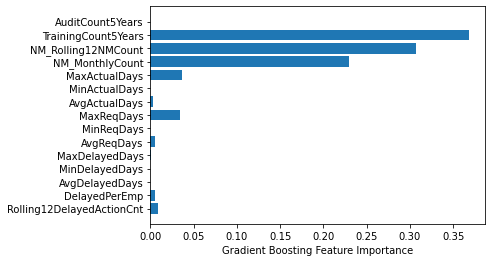

In [20]:
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Gradient Boosting Feature Importance")

In [21]:
sorted_idx = model.feature_importances_.argsort()
sorted_idx

array([ 3,  9, 14,  2,  6,  4,  8,  5,  1,  0,  7, 10, 11, 12, 13],
      dtype=int64)

Text(0.5, 0, 'Gradient Boosting Feature Importance')

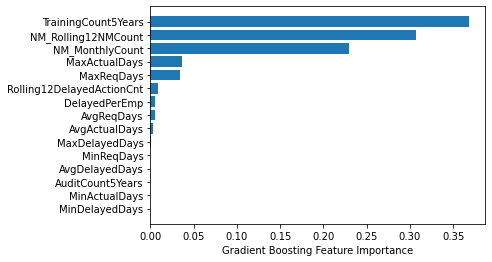

In [22]:
sorted_idx = model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("Gradient Boosting Feature Importance")

In [23]:
rank = pd.DataFrame( (np.arange(1,len(model.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["GradientBoosting"])
print("Feature Importance Ranking:")
rank

Feature Importance Ranking:


,GradientBoosting
TrainingCount5Years,1
NM_Rolling12NMCount,2
NM_MonthlyCount,3
MaxActualDays,4
MaxReqDays,5
Rolling12DelayedActionCnt,6
DelayedPerEmp,7
AvgReqDays,8
AvgActualDays,9
MaxDelayedDays,10


## Scikit-Learn Histogram-based Gradient Boosting Approach

This part implements a histogram-based gradient boosting Approach  for the classification problem.
The HistGradientBoostingClassifier also comes from the Scikit-Learn package.

### Import Libraries

In [24]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

### Import Model

In [25]:
model = HistGradientBoostingClassifier()

### Cross-validation

In [26]:
start = time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1)

speed["HistGradientBoosting"] = np.round(time() - start, 3)
accuracy["HistGradientBoosting"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['HistGradientBoosting']}\nStd: {np.std(score):.3f}\nRun time: {speed['HistGradientBoosting']}s"
)

Mean Accuracy: 0.333
Std: 0.000
Run time: 2.144s


In [27]:
score

array([0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333

### fit the model 

In [28]:
# fit the model on the whole dataset
model.fit(X, y)

HistGradientBoostingClassifier()

###  Feature Importance

As an experimental approach, feature importance is not provided by this approach (see API and attribute of the model below), although such requests can be found in the community (https://github.com/scikit-learn/scikit-learn/issues/16064).

In [29]:
dir(model)

['_VALID_LOSSES',
 '__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_baseline_prediction',
 '_bin_data',
 '_check_early_stopping_loss',
 '_check_early_stopping_scorer',
 '_check_n_features',
 '_clear_state',
 '_compute_partial_dependence_recursion',
 '_encode_y',
 '_estimator_type',
 '_get_loss',
 '_get_param_names',
 '_get_small_trainset',
 '_get_tags',
 '_is_fitted',
 '_more_tags',
 '_predictors',
 '_print_iteration_stats',
 '_random_seed',
 '_raw_predict',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_should_stop',
 '_use_validation_data',
 '_validate_data',
 '_valid

### Performance Comparison

In [30]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': 0.633, 'HistGradientBoosting': 0.333}

In [31]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'HistGradientBoosting': 2.144, 'GradientBoosting': 7.093}

"Instead of finding the split points on the sorted feature values, histogram-based algorithm buckets continuous feature values into discrete bins and uses these bins to construct feature histograms during training. (https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html)"
As a result, this histogram-based approach runs much faster than its original approach.
The time consumption of the histogram-based approach is much less than the previous one.

However, its accuracy is only 33%, which is inferior to the original approach (65.8% accuracy).
The reason for the inferior performance roots on the consequence of its training process and the limited dataset.
Estimators that construct the histogram only access subsets of the completed dataset.
When the dataset has a decent amount of instance and its subsets have similar data distribution, estimators learns from the distribution of the dataset.
In contrast, subsets fail to represent the distribution of the dataset when the dataset only have a few instances.
In this case, these subsets affect the estimators, causing ithe nferior performance.

## XGBoost

XGBoost is an advanced implementation of gradient boosting algorithm.
This section applies XGBClassifier from XGBoost to learn the prediction model.

### Import Libraries

In [32]:
#! pip install xgboost
from xgboost import XGBClassifier, plot_importance

### import model

In [33]:
model = XGBClassifier()
#model = XGBClassifier(learning_rate=0.02, n_estimators=600, objective='binary:logistic', silent=True, nthread=1)


### cross-validation

In [34]:
start = time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1)

speed["XGB"] = np.round(time() - start, 3)
accuracy["XGB"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['XGB']}\nStd: {np.std(score):.3f}\nRun time: {speed['XGB']}s"
)

Mean Accuracy: 0.605
Std: 0.244
Run time: 4.189s


In [35]:
#score

### Performance Comparison

The performances of XGBoost are similar to the GradientBoosting's.

In [36]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': 0.633, 'XGB': 0.605, 'HistGradientBoosting': 0.333}

In [37]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'HistGradientBoosting': 2.144, 'XGB': 4.189, 'GradientBoosting': 7.093}

### Fit The Model (Before Parametere Optimization)

In [38]:
model.fit(X, y, eval_metric='auc')

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:892: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

### Plot Feature Importance (Before Parametere Optimization)

Feature importance is calculated by 3 approaches:  weight, gain, and cover.

- gain  is the average gain of splits which use the feature
- weight is the number of times a feature appears in a tree
- cover is the average coverage of splits which use the feature where coverage is defined as the number of samples affected by the split

This report record the "gain" approach of feature importance for comparison.

In [39]:
model.get_booster().get_score(importance_type="gain")

{'TrainingCount5Years': 1.5378739814,
 'AvgDelayedDays': 0.4474608838819285,
 'NM_MonthlyCount': 1.3757188630000001,
 'MaxDelayedDays': 0.41414853640000004,
 'Rolling12DelayedActionCnt': 0.4069084077999999,
 'AvgReqDays': 0.011747607267424997,
 'AvgActualDays': 0.009767331086206898}

<AxesSubplot:>

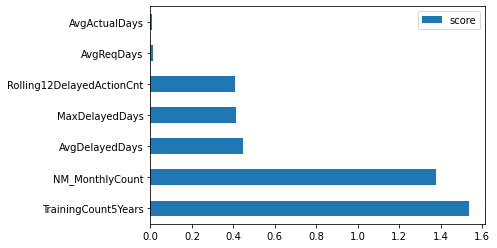

In [40]:
feature_important = model.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

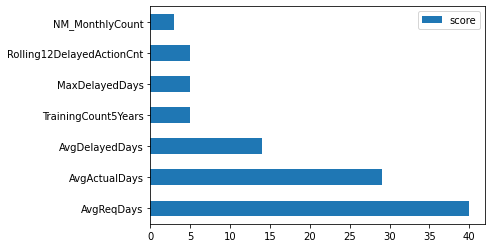

In [41]:
feature_important = model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

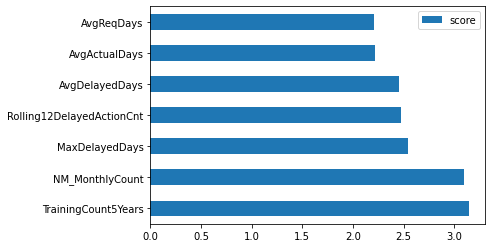

In [42]:
feature_important = model.get_booster().get_score(importance_type='cover')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

In [43]:
feature_important_ = pd.DataFrame.from_dict(feature_important, orient='index', columns=['feature_importance'])
feature_important_ = feature_important_.sort_values(by='feature_importance', ascending=False)
rank_serial = range(1, len(feature_important_) +1)
#list(rank_serial)

feature_important_['XGBoost (Default)']= list(rank_serial) #rank
ranking_xbg_b = feature_important_.drop("feature_importance", axis=1)
ranking_xbg_b 

,XGBoost (Default)
TrainingCount5Years,1
NM_MonthlyCount,2
MaxDelayedDays,3
Rolling12DelayedActionCnt,4
AvgDelayedDays,5
AvgActualDays,6
AvgReqDays,7


In [44]:
model.get_params()

{'objective': 'binary:logistic',
 'use_label_encoder': True,
 'base_score': 0.5,
 'booster': 'gbtree',
 'colsample_bylevel': 1,
 'colsample_bynode': 1,
 'colsample_bytree': 1,
 'gamma': 0,
 'gpu_id': -1,
 'importance_type': 'gain',
 'interaction_constraints': '',
 'learning_rate': 0.300000012,
 'max_delta_step': 0,
 'max_depth': 6,
 'min_child_weight': 1,
 'missing': nan,
 'monotone_constraints': '()',
 'n_estimators': 100,
 'n_jobs': 4,
 'num_parallel_tree': 1,
 'random_state': 0,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'scale_pos_weight': 1,
 'subsample': 1,
 'tree_method': 'exact',
 'validate_parameters': 1,
 'verbosity': None}

#### Hyperparameter Optimization

The XGBoost model requires hyperparameter tuning to improve and fully leverage its advantages over other algorithms.

https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

In [45]:
# A parameter grid for XGBoost
params = {
        'min_child_weight': [1, 2, 3],
        'gamma': [0, 0.5, 1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [5, 6, 7]
        }
# fit model no training data
#xgb = XGBClassifier(learning_rate=0.02, n_estimators=600, objective='binary:logistic', silent=True, nthread=1)
xgb = XGBClassifier()
folds = 3
param_comb = 5

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
#score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1)

Randomized search is applied for tuning hyperparameters.
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [46]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
random_search = RandomizedSearchCV(xgb, param_distributions=params,n_iter=param_comb, scoring='roc_auc', n_jobs=-1, cv=cv, verbose=0, random_state=0 )

In [47]:
random_search.fit(X, y, eval_metric='auc')

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:892: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=50, n_splits=5, random_state=0),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, gamma=None,
                                           gpu_id=None, importance_type='gain',
                                           interaction_constraints=None,
                                           learning_rate=None,
                                           max_delta_step=None, max_depth=None,
                                           min_child_weigh...
                                           num_parallel_tree=None,
                                           random_state=None, reg_alpha=None,
                                           reg_lambda=None,
                                           scale_pos_weight=Non

In [48]:
print('\n Best hyperparameters:')
print(random_search.best_params_)
print('\n Best estimator:')
print(random_search.best_estimator_)


 Best hyperparameters:
{'subsample': 0.8, 'min_child_weight': 1, 'max_depth': 6, 'gamma': 0.5, 'colsample_bytree': 0.6}

 Best estimator:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.6, gamma=0.5, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.8,
              tree_method='exact', validate_parameters=1, verbosity=None)


In [49]:
#dir(random_search.best_estimator_)

In [50]:
#check importance_type
random_search.best_estimator_.importance_type

'gain'

In [51]:
random_search.best_estimator_.feature_importances_ 

array([0.07012209, 0.07542349, 0.19199921, 0.        , 0.05338017,
       0.        , 0.34302276, 0.        , 0.        , 0.        ,
       0.        , 0.13138352, 0.        , 0.13466877, 0.        ],
      dtype=float32)

In [52]:
print("Feature Importance: \n ", random_search.best_estimator_.get_booster().get_score(importance_type='gain'))

Feature Importance: 
  {'MinReqDays': 3.33333349, 'Rolling12DelayedActionCnt': 0.6814134319999999, 'NM_MonthlyCount': 1.276723115, 'AvgDelayedDays': 1.8657578633333334, 'TrainingCount5Years': 1.3086475585, 'MaxDelayedDays': 0.518723309, 'DelayedPerEmp': 0.732929885}


<AxesSubplot:>

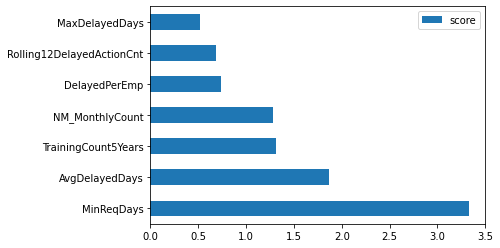

In [53]:
feature_important_opt = random_search.best_estimator_.get_booster().get_score(importance_type='gain')
keys = list(feature_important_opt.keys())
values = list(feature_important_opt.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

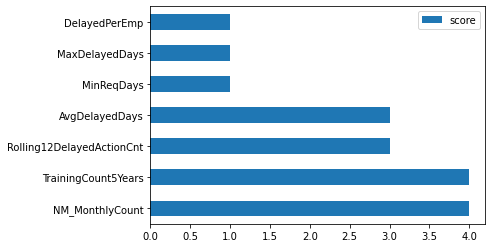

In [54]:
feature_important_opt = random_search.best_estimator_.get_booster().get_score(importance_type='weight')
keys = list(feature_important_opt.keys())
values = list(feature_important_opt.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

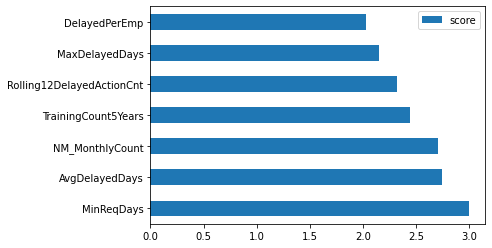

In [55]:
feature_important_opt = random_search.best_estimator_.get_booster().get_score(importance_type='cover')
keys = list(feature_important_opt.keys())
values = list(feature_important_opt.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

In [56]:
feature_important_ = pd.DataFrame.from_dict(feature_important, orient='index', columns=['feature_importance'])
feature_important_ = feature_important_.sort_values(by='feature_importance', ascending=False)
rank_serial = range(1, len(feature_important_) +1)
#list(rank_serial)

feature_important_['XGBoost (Optimised)']= list(rank_serial) #rank
ranking_xbg_o = feature_important_.drop("feature_importance", axis=1)

change =pd.DataFrame( ranking_xbg_b["XGBoost (Default)"]-ranking_xbg_o['XGBoost (Optimised)'], columns=["ranking change"])

pd.concat([ranking_xbg_o, ranking_xbg_b, change], axis=1)

,XGBoost (Optimised),XGBoost (Default),ranking change
TrainingCount5Years,1,1,0
NM_MonthlyCount,2,2,0
MaxDelayedDays,3,3,0
Rolling12DelayedActionCnt,4,4,0
AvgDelayedDays,5,5,0
AvgActualDays,6,6,0
AvgReqDays,7,7,0


The ranking of feature importance keeps the same after the model was trained with optimised hyperparameters.
In the optimised model, the feature of the top two ranking features become less dominate in constructing model as values of features importance become more evenly distributed than before.

In [57]:
feature_important_ = pd.DataFrame.from_dict(feature_important, orient='index', columns=['feature_importance'])
feature_important_ = feature_important_.sort_values(by='feature_importance', ascending=False)
rank_serial = range(1, len(feature_important_) +1)
#list(rank_serial)

feature_important_['XGBoost (Optimised)']= list(rank_serial) #rank
ranking_ = feature_important_.drop("feature_importance", axis=1)

rank = pd.concat([rank, ranking_xbg_o], axis=1)
rank

,GradientBoosting,XGBoost (Optimised)
TrainingCount5Years,1,1.0
NM_Rolling12NMCount,2,NaN
NM_MonthlyCount,3,2.0
MaxActualDays,4,NaN
MaxReqDays,5,NaN
Rolling12DelayedActionCnt,6,4.0
DelayedPerEmp,7,NaN
AvgReqDays,8,7.0
AvgActualDays,9,6.0
MaxDelayedDays,10,3.0


## LightGBM

### Import Libraries

In [58]:
#!conda install -c conda-forge lightgbm
import lightgbm as lgb
from lightgbm import LGBMClassifier

### import model

In [59]:
model = LGBMClassifier()


### cross-validation

In [60]:
start = time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=-1)

speed["LGBM"] = np.round(time() - start, 3)
accuracy["LGBM"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['LGBM']}\nStd: {np.std(score):.3f}\nRun time: {speed['LGBM']}s"
)

Mean Accuracy: 0.333
Std: 0.000
Run time: 1.622s


In [61]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': 0.633,
 'XGB': 0.605,
 'HistGradientBoosting': 0.333,
 'LGBM': 0.333}

Notice that this accuracy is significantly lower than GradientBoosting and XGBoost.
Therefore, it is not that surprising that the feature importance values equal to zeros, even after hyperparameter optimization (see below). 

In [62]:
#score

### fit the model 

In [63]:
model.fit(X, y)

LGBMClassifier()

### Plot Feature Importance

The default model fails to achieve feature importance when its accuracy is relatively low.

In [64]:
print("Feature Importance: ",model.feature_importances_)

Feature Importance:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Text(0.5, 0, 'LightGBM Feature Importance')

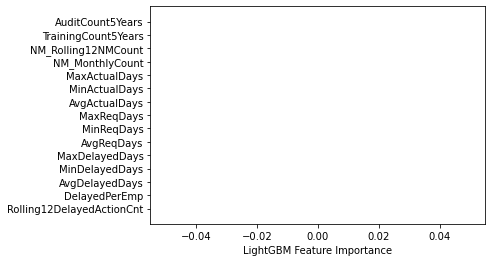

In [65]:
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("LightGBM Feature Importance")

In [66]:
#model.get_params()

### Hyperparameter Optimaztion

In [67]:
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
param_test ={'num_leaves': sp_randint(6, 50), 
             'min_child_samples': sp_randint(100, 500), 
             'min_child_weight': [1e-5, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4],
             'subsample': sp_uniform(loc=0.2, scale=0.8), 
             'colsample_bytree': sp_uniform(loc=0.4, scale=0.6),
             'reg_alpha': [0, 1e-1, 1, 2, 5, 7, 10, 50, 100],
             'reg_lambda': [0, 1e-1, 1, 5, 10, 20, 50, 100]}

fit_params={"early_stopping_rounds":30, 
            "eval_metric" : 'auc', 
            "eval_set" : [(X_test,y_test)],
            'eval_names': ['valid'],
            #'callbacks': [lgb.reset_parameter(learning_rate=learning_rate_010_decay_power_099)],
            'verbose': 100,
            'categorical_feature': 'auto'}

In [68]:
#This parameter defines the number of HP points to be tested
n_HP_points_to_test = 100

import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#n_estimators is set to a "large value". The actual number of trees build will depend on early stopping and 5000 define only the absolute maximum
clf = lgb.LGBMClassifier(max_depth=-1, random_state=314, silent=True, metric='None', n_jobs=4, n_estimators=5000)
gs = RandomizedSearchCV(
    estimator=clf, param_distributions=param_test, 
    n_iter=n_HP_points_to_test,
    scoring='roc_auc',
    cv=3,
    refit=True,
    random_state=0,
    verbose=False)

In [69]:
gs.fit(X_train, y_train, **fit_params)

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Ear

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Ear

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Ear

[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[1]	valid's auc: 0.5


RandomizedSearchCV(cv=3,
                   estimator=LGBMClassifier(metric='None', n_estimators=5000,
                                            n_jobs=4, random_state=314),
                   n_iter=100,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000000007B77040>,
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000000007B7B8B0>,
                                        'min_child_weight': [1e-05, 0.001, 0.01,
                                                             0.1, 1, 10.0,
                                                             100.0, 1000.0,
                                                             10000.0],
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000000007B7B9A0>,
                                        'reg_alpha': [0, 0.1, 1, 2, 5, 7, 10,
         

In [70]:
print('Best score reached: {} with params: {} '.format(gs.best_score_, gs.best_params_))

Best score reached: 0.5 with params: {'colsample_bytree': 0.7292881023563949, 'min_child_samples': 217, 'min_child_weight': 1e-05, 'num_leaves': 9, 'reg_alpha': 2, 'reg_lambda': 100, 'subsample': 0.5389238394711238} 


### Fit the final model

In [71]:
clf_final = LGBMClassifier(**clf.get_params())

In [72]:
#set optimal parameters
clf_final.set_params(**gs.best_params_)

LGBMClassifier(colsample_bytree=0.7292881023563949, metric='None',
               min_child_samples=217, min_child_weight=1e-05, n_estimators=5000,
               n_jobs=4, num_leaves=9, random_state=314, reg_alpha=2,
               reg_lambda=100, subsample=0.5389238394711238)

In [73]:
#fit on the whole dataset
clf_final.fit(X, y)

LGBMClassifier(colsample_bytree=0.7292881023563949, metric='None',
               min_child_samples=217, min_child_weight=1e-05, n_estimators=5000,
               n_jobs=4, num_leaves=9, random_state=314, reg_alpha=2,
               reg_lambda=100, subsample=0.5389238394711238)

### Feature Importance

The values of feature importance all equals to zeros even with optimal hyperparameters.

In [74]:
clf_final.feature_importances_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

This suggests that the optimised model of thelightGBM approach also fails to achieve feature importance in this case.

## Catboost

### Import Libraries

In [75]:
from catboost import CatBoostClassifier

### import model

In [76]:
model = CatBoostClassifier()

### cross-validation

In [77]:
start = time()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="accuracy", cv=cv, n_jobs=4)

speed["CatBoost"] = np.round(time() - start, 3)
accuracy["CatBoost"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['CatBoost']}\nStd: {np.std(score):.3f}\nRun time: {speed['CatBoost']}s"
)

Mean Accuracy: 0.697
Std: 0.257
Run time: 130.234s


In [78]:
#score

### fit the model 

In [79]:
model.fit(X, y,verbose_eval=False)

### Plot Feature Importance

In [80]:
print("Feature Importance: ",model.feature_importances_)

Feature Importance:  [ 7.71993885  8.56782952  7.37295708  0.23839668  9.58185151  5.48829867
  6.61653023  8.49250067  6.20588303 11.24807859  3.17545354  8.29574046
 10.14871373  5.3479403   1.49988714]


Text(0.5, 0, 'CatBoostRegressor Feature Importance')

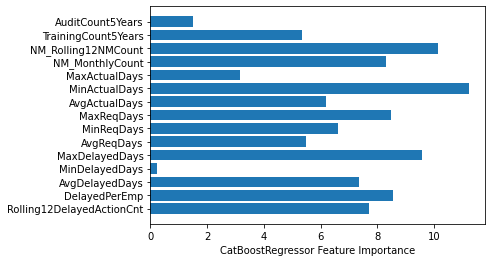

In [81]:
plt.barh(model.feature_names_, model.feature_importances_)
plt.xlabel("CatBoostRegressor Feature Importance")

### Hyperparameter Optimaztion

In [82]:
parameters = {
    'depth': [3,4,5],
    'learning_rate' : [0.005,0.01,0.02]
    }


In [83]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
CBC = CatBoostClassifier()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
Grid_CBC = GridSearchCV(estimator=CBC, param_grid = parameters,cv = cv, n_jobs=-1)


In [84]:
Grid_CBC.fit(X_train, y_train,verbose_eval=False)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=5, random_state=0),
             estimator=<catboost.core.CatBoostClassifier object at 0x0000000007E379D0>,
             n_jobs=-1,
             param_grid={'depth': [3, 4, 5],
                         'learning_rate': [0.005, 0.01, 0.02]})

In [85]:
print('Best score reached: {} with params: {} '.format(Grid_CBC.best_score_, Grid_CBC.best_params_))

Best score reached: 0.6566666666666667 with params: {'depth': 3, 'learning_rate': 0.01} 


In [86]:
Grid_CBC.best_estimator_.get_feature_importance()

array([ 5.7386206 ,  9.41884586,  5.7650068 ,  0.0741454 ,  4.62164295,
        2.42841831,  5.06521003,  5.33670712,  5.54614495,  8.38002718,
        1.93224757, 36.32588783,  5.79597812,  2.90547419,  0.66564308])

### Fit the final model

In [87]:
Grid_CBC.best_params_

{'depth': 3, 'learning_rate': 0.01}

In [88]:
CBC_final = CatBoostClassifier(**CBC.get_params())

In [89]:
#set optimal parameters
CBC_final.set_params(**Grid_CBC.best_params_)

In [90]:
#fit on the whole dataset
CBC_final.fit(X, y,verbose_eval=False)

### Plot Feature Importance

In [91]:
print("Feature Importance: ",CBC_final.feature_importances_)

Feature Importance:  [ 7.93668536 12.05947977  5.67635647  0.19222108  7.05559532  5.47941133
  6.44164569  8.85567109  5.86076572 11.06205033  3.19338145  6.04011752
 13.76090728  5.41050929  0.97520231]


Text(0.5, 0, 'CatBoostRegressor Feature Importance (optimised hyperparameters)')

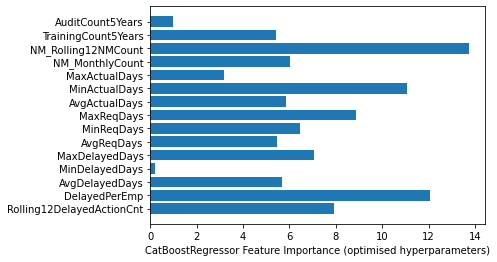

In [92]:
plt.barh(CBC_final.feature_names_, CBC_final.feature_importances_)
plt.xlabel("CatBoostRegressor Feature Importance (optimised hyperparameters)")

Text(0.5, 0, 'CatBoostRegressor Feature Importance')

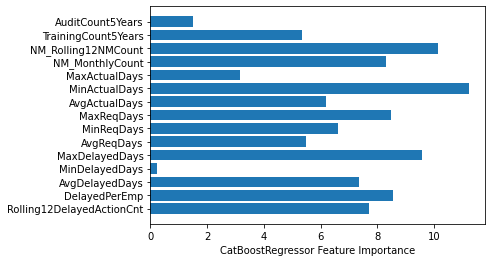

In [93]:
plt.barh(model.feature_names_, model.feature_importances_)
plt.xlabel("CatBoostRegressor Feature Importance")

In [94]:
sorted_idx = model.feature_importances_.argsort()
rank_1 = pd.DataFrame( (np.arange(1,len(model.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["CatBoost (Default)"])
sorted_idx = CBC_final.feature_importances_.argsort()
rank_2 = pd.DataFrame( (np.arange(1,len(CBC_final.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["CatBoost (Optimised)"])
change =pd.DataFrame( rank_1["CatBoost (Default)"]-rank_2["CatBoost (Optimised)"], columns=["ranking change"])
ranking_ = pd.concat([rank_2, rank_1, change], axis=1)
ranking_

,CatBoost (Optimised),CatBoost (Default),ranking change
NM_Rolling12NMCount,1,2,1
DelayedPerEmp,2,4,2
MinActualDays,3,1,-2
MaxReqDays,4,5,1
Rolling12DelayedActionCnt,5,7,2
MaxDelayedDays,6,3,-3
MinReqDays,7,9,2
NM_MonthlyCount,8,6,-2
AvgActualDays,9,10,1
AvgDelayedDays,10,8,-2


The optimised hyperparameters can affect the construction of the prediction model.
The ranking of the feature importance slightly changed as optimised hyperparameters were introduced to the model.
Risen from the 2nd, ``NM_Rolling12NMCount`` became the most important features.
``Rolling12DelayedActionCnt``also became a more important feature than before.
This case suggests that tuning hyperparameter may be necessary when Catboost approach deals with a complex dataset in future.

In [95]:
rank = pd.concat([rank, rank_2], axis=1)
#rank

In [96]:
#save the ranking file
rank.index.name = "Features"
rank.to_csv('result/Feature_importance_ranking_classifiers.csv')

## Section Summary 

This section investigates five implementations for a safety classification problem.
Three approaches (e.g. GradientBoosting, XGB, and CatBoost) reach relatively high accuracies with feature importance.
Their accuracies have a roughly inverted relationship with their time consumptions, suggesting a balance that worthies considering when implement.

In addition, the histogram-based approaches (e.g. Histogram-based Gradient Boosting and LightGBM) have inferior performance in this case.
Because the dataset is relatively small in this study, these two approaches still worth a try when they face a complex dataset in the future.

In [97]:
rank

,GradientBoosting,XGBoost (Optimised),CatBoost (Optimised)
Features,,,
TrainingCount5Years,1,1.0,12
NM_Rolling12NMCount,2,NaN,1
NM_MonthlyCount,3,2.0,8
MaxActualDays,4,NaN,13
MaxReqDays,5,NaN,4
Rolling12DelayedActionCnt,6,4.0,5
DelayedPerEmp,7,NaN,2
AvgReqDays,8,7.0,11
AvgActualDays,9,6.0,9


In [98]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'CatBoost': 0.697,
 'GradientBoosting': 0.633,
 'XGB': 0.605,
 'HistGradientBoosting': 0.333,
 'LGBM': 0.333}

In [99]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'LGBM': 1.622,
 'HistGradientBoosting': 2.144,
 'XGB': 4.189,
 'GradientBoosting': 7.093,
 'CatBoost': 130.234}

# Section 2: Regression

The second section applies five implementations of the GBoost and the XGBoost algorithms for regression problem.

## Data Preprocessing

### Import Libraries

In [100]:
import numpy as np
import pandas as pd
from time import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scipy import stats




###  Import Dataset

In [101]:
#import dataset
data = pd.read_csv('dataset/impact.csv')
# split the traing and testing datasets
X = data.drop('TRIFR',1)
y = data['TRIFR']


### Skew

transform features with skew > 1 

In [102]:
import copy
X_skewed = copy.deepcopy(X)
for col in range(X_skewed.shape[1]):
    if stats.mstats.skew(X_skewed.iloc[:, col]).data >1 or stats.mstats.skew(X_skewed.iloc[:, col]).data < -1 :
        if len(X_skewed[X_skewed.iloc[:, col]>0]) < X_skewed.shape[0]:
            # to shew, each value in the column should be positive number
            pass
        else:
            X_skewed.iloc[:, col] = np.log(X_skewed.iloc[:, col])
    else:
        pass

In [103]:
stats.mstats.skew(X).data

array([-0.35461034, -0.32561725,  2.19824437,  3.47439614,  0.05099458,
        0.03762476,  0.16789008, -0.92026225, -0.57649107, -0.407614  ,
       -0.60945159,  0.77786451, -0.64815153,  0.46823692,  1.79700391])

In [104]:
stats.mstats.skew(X_skewed).data

array([-0.35461034, -0.32561725,  1.57089682,  3.47439614,  0.05099458,
        0.03762476,  0.16789008, -0.92026225, -0.57649107, -0.407614  ,
       -0.60945159,  0.77786451, -0.64815153,  0.46823692,  1.79700391])

In [105]:
X

,Rolling12DelayedActionCnt,DelayedPerEmp,AvgDelayedDays,MinDelayedDays,MaxDelayedDays,AvgReqDays,MinReqDays,MaxReqDays,AvgActualDays,MinActualDays,MaxActualDays,NM_MonthlyCount,NM_Rolling12NMCount,TrainingCount5Years,AuditCount5Years
0,132,0.61,65,1,699,146,-699,619,212,-52,708,2,12,0,0
1,92,0.42,78,1,528,78,-528,577,156,0,581,1,31,5,9
2,90,0.41,81,1,528,66,-528,577,148,0,581,3,33,3,0
3,89,0.41,82,1,528,58,-528,371,141,0,428,4,35,0,0
4,132,0.61,65,1,699,146,-699,619,211,-52,708,1,20,0,0
5,131,0.60,65,1,699,153,-699,619,218,-52,708,2,22,3,11
6,134,0.62,64,1,699,157,-699,619,222,-52,708,2,24,1,0
7,134,0.62,62,1,699,161,-699,619,223,-52,708,4,27,3,0
8,117,0.54,59,1,457,170,-204,577,230,-52,708,2,27,2,4
9,118,0.54,91,1,528,106,-528,577,198,0,581,6,31,3,12


In [106]:
X_skewed

,Rolling12DelayedActionCnt,DelayedPerEmp,AvgDelayedDays,MinDelayedDays,MaxDelayedDays,AvgReqDays,MinReqDays,MaxReqDays,AvgActualDays,MinActualDays,MaxActualDays,NM_MonthlyCount,NM_Rolling12NMCount,TrainingCount5Years,AuditCount5Years
0,132,0.61,4.174387,0.000000,699,146,-699,619,212,-52,708,2,12,0,0
1,92,0.42,4.356709,0.000000,528,78,-528,577,156,0,581,1,31,5,9
2,90,0.41,4.394449,0.000000,528,66,-528,577,148,0,581,3,33,3,0
3,89,0.41,4.406719,0.000000,528,58,-528,371,141,0,428,4,35,0,0
4,132,0.61,4.174387,0.000000,699,146,-699,619,211,-52,708,1,20,0,0
5,131,0.60,4.174387,0.000000,699,153,-699,619,218,-52,708,2,22,3,11
6,134,0.62,4.158883,0.000000,699,157,-699,619,222,-52,708,2,24,1,0
7,134,0.62,4.127134,0.000000,699,161,-699,619,223,-52,708,4,27,3,0
8,117,0.54,4.077537,0.000000,457,170,-204,577,230,-52,708,2,27,2,4
9,118,0.54,4.510860,0.000000,528,106,-528,577,198,0,581,6,31,3,12


In [107]:
X = X_skewed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [108]:
#keep record for comparison
accuracy = {}
speed = {}

## GBoost: Scikit-Learn Gradient Boosting Approach

### Import Libraries

In [109]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold


### import model

In [110]:
model = GradientBoostingRegressor()

### cross-validation

In [111]:
start = time()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

speed["GradientBoosting"] = np.round(time() - start, 3)
accuracy["GradientBoosting"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['GradientBoosting']}\nStd: {np.std(score):.3f}\nRun time: {speed['GradientBoosting']}s"
)

Mean Accuracy: -1.459
Std: 1.753
Run time: 3.78s


In [112]:
#score

### fit the model 

In [113]:
# fit the model on the whole dataset
model.fit(X, y)

GradientBoostingRegressor()

### Plot Feature Importance

In [114]:
print("The impurity-based feature importances :\n", model.feature_importances_)

The impurity-based feature importances :
 [5.17949996e-01 4.06008469e-01 1.13311716e-02 2.12186580e-06
 2.83203825e-03 1.92741795e-02 3.69388199e-03 6.60144266e-04
 1.20691332e-02 9.07013229e-03 4.30236166e-05 2.48508477e-03
 1.36589673e-02 2.71041455e-04 6.50614763e-04]


In [115]:
#sorted_idx = model.feature_importances_.argsort()
#sorted_idx

Text(0.5, 0, 'Gradient Boosting Feature Importance')

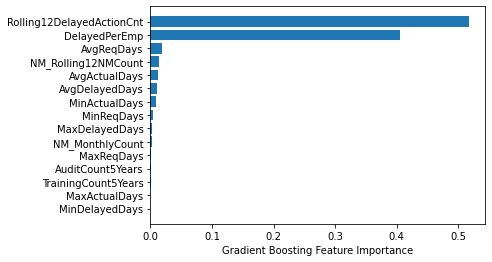

In [116]:
sorted_idx = model.feature_importances_.argsort()
plt.barh(X.columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("Gradient Boosting Feature Importance")

In [117]:
rank_c = pd.DataFrame( (np.arange(1,len(model.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["GradientBoosting"])
print("Feature Importance Ranking:")
rank_c

Feature Importance Ranking:


,GradientBoosting
Rolling12DelayedActionCnt,1
DelayedPerEmp,2
AvgReqDays,3
NM_Rolling12NMCount,4
AvgActualDays,5
AvgDelayedDays,6
MinActualDays,7
MinReqDays,8
MaxDelayedDays,9
NM_MonthlyCount,10


## Scikit-Learn Histogram-based Gradient Boosting Approach

### Import Libraries

In [118]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

### import model

In [119]:
model = HistGradientBoostingRegressor()

### cross-validation

In [120]:
start = time()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

speed["HistGradientBoosting"] = np.round(time() - start, 3)
accuracy["HistGradientBoosting"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['HistGradientBoosting']}\nStd: {np.std(score):.3f}\nRun time: {speed['HistGradientBoosting']}s"
)

Mean Accuracy: -5.122
Std: 1.674
Run time: 5.728s


In [121]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': -1.459, 'HistGradientBoosting': -5.122}

In [122]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'GradientBoosting': 3.78, 'HistGradientBoosting': 5.728}

### fit the model 

In [123]:
# fit the model on the whole dataset
model.fit(X, y)

HistGradientBoostingRegressor()

###  Feature Importance

As an experimental approach, feature importance is not provided by this approach (see API and attribute of the model below)).

In [124]:
dir(model)

['_VALID_LOSSES',
 '__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_baseline_prediction',
 '_bin_data',
 '_check_early_stopping_loss',
 '_check_early_stopping_scorer',
 '_check_n_features',
 '_clear_state',
 '_compute_partial_dependence_recursion',
 '_encode_y',
 '_estimator_type',
 '_get_loss',
 '_get_param_names',
 '_get_small_trainset',
 '_get_tags',
 '_is_fitted',
 '_more_tags',
 '_predictors',
 '_print_iteration_stats',
 '_random_seed',
 '_raw_predict',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_should_stop',
 '_use_validation_data',
 '_validate_data',
 '_valid

## XGBoost

### Import Libraries

In [125]:
#! pip install xgboost
from xgboost import XGBRegressor, plot_importance

### import model

In [126]:
model = XGBRegressor()

### cross-validation

In [127]:
start = time()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

speed["XGB"] = np.round(time() - start, 3)
accuracy["XGB"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['XGB']}\nStd: {np.std(score):.3f}\nRun time: {speed['XGB']}s"
)

Mean Accuracy: -1.581
Std: 1.746
Run time: 6.869s


In [128]:
#score

### fit the model 

In [129]:
# fit the model on the whole dataset
#model = XGBRegressor()
model.fit(X, y)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.300000012, max_delta_step=0, max_depth=6,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=100, n_jobs=4, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

### Plot Feature Importance

As mensioned in the first section, the importance of this approach is calculated thought "weight", "gain" or "cover" method.

"weight" is the number of times a feature appears in a tree.

"gain" is the average gain of splits which use the feature.

"cover" is the average coverage of splits which use the feature where coverage is defined as the number of samples affected by the split.

In [130]:
print("Feature Importance: ",model.feature_importances_)

Feature Importance:  [8.1917024e-01 0.0000000e+00 9.7510934e-02 0.0000000e+00 5.0932989e-02
 1.2130307e-02 0.0000000e+00 0.0000000e+00 1.9593060e-04 0.0000000e+00
 3.3575142e-07 3.2842721e-07 1.6343715e-02 2.8297000e-03 8.8552712e-04]


In [131]:
model.importance_type

'gain'

<AxesSubplot:>

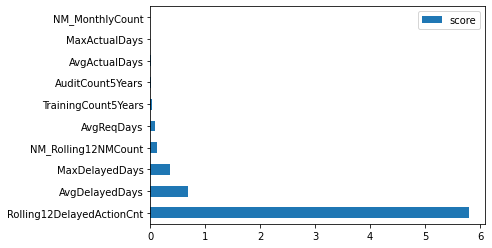

In [132]:
feature_important = model.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

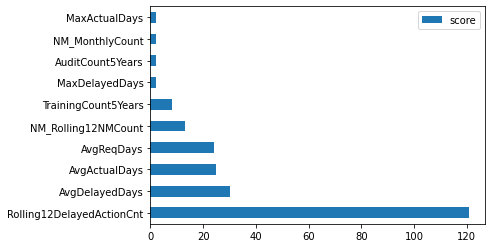

In [133]:
feature_important = model.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

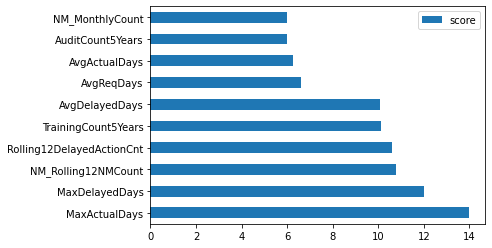

In [134]:
feature_important = model.get_booster().get_score(importance_type='cover')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

Apply a build-in plot_importance() function as an alternative method to plot feature importance

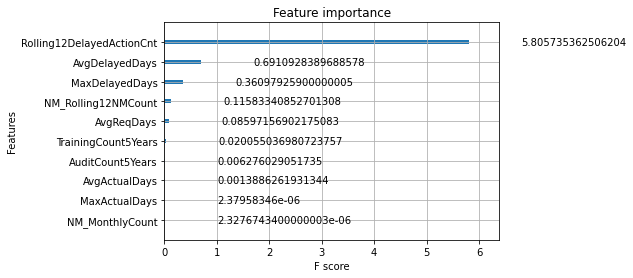

<Figure size 1152x864 with 0 Axes>

In [135]:
plot_importance(model, importance_type='gain')
plt.figure(figsize = (16, 12))
plt.show()


In [136]:
feature_important = model.get_booster().get_score(importance_type='gain')
feature_important_ = pd.DataFrame.from_dict(feature_important, orient='index', columns=['feature_importance'])
feature_important_ = feature_important_.sort_values(by='feature_importance', ascending=False)
rank_serial = range(1, len(feature_important_) +1)
#list(rank_serial)

feature_important_['XGBoost (Default)']= list(rank_serial) #rank
ranking_xbg_c_b = feature_important_.drop("feature_importance", axis=1)
ranking_xbg_c_b 

,XGBoost (Default)
Rolling12DelayedActionCnt,1
AvgDelayedDays,2
MaxDelayedDays,3
NM_Rolling12NMCount,4
AvgReqDays,5
TrainingCount5Years,6
AuditCount5Years,7
AvgActualDays,8
MaxActualDays,9
NM_MonthlyCount,10


#### Parameter Optimization

In [137]:
# A parameter grid for XGBoost
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 2],
        #'subsample': [0.6, 0.8, 1.0],
        #'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

In [138]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)
model = XGBRegressor()
xgb_grid = GridSearchCV(model, params, scoring="neg_mean_absolute_error", cv = cv, n_jobs = -1,verbose=False)

In [139]:
xgb_grid.fit(X, y)

GridSearchCV(cv=RepeatedKFold(n_repeats=10, n_splits=5, random_state=0),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, gamma=None,
                                    gpu_id=None, importance_type='gain',
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=na...constraints=None,
                                    n_estimators=100, n_jobs=None,
                                    num_parallel_tree=None, random_state=None,
                                    reg_alpha=None, reg_lambda=None,
                                    scale_pos_weight=None, subsample=None,
                      

In [140]:
print(xgb_grid.best_score_)
print(xgb_grid.best_params_)

-1.5748042417450594
{'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 1}


### Feature Importance of The Best Estimator

In [141]:
xgb_grid.best_estimator_.get_booster().get_score(importance_type='gain')

{'Rolling12DelayedActionCnt': 37.073231759947376,
 'AvgDelayedDays': 10.37497046,
 'AvgReqDays': 0.9188615073333333,
 'NM_Rolling12NMCount': 0.749077976,
 'AvgActualDays': 0.62513113,
 'TrainingCount5Years': 0.85164392}

<AxesSubplot:>

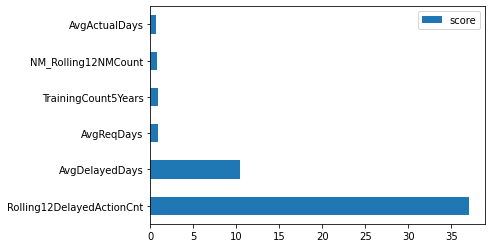

In [142]:
feature_important = xgb_grid.best_estimator_.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

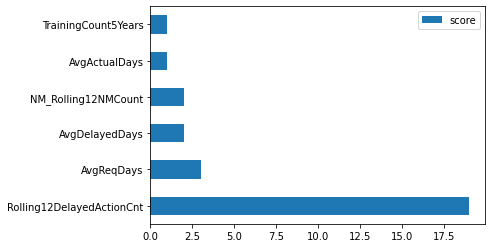

In [143]:
feature_important = xgb_grid.best_estimator_.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

<AxesSubplot:>

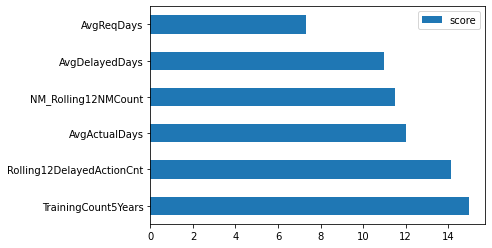

In [144]:
feature_important = xgb_grid.best_estimator_.get_booster().get_score(importance_type='cover')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.plot(kind='barh')

In [145]:
feature_important = xgb_grid.best_estimator_.get_booster().get_score(importance_type='gain')
feature_important_ = pd.DataFrame.from_dict(feature_important, orient='index', columns=['feature_importance'])
feature_important_ = feature_important_.sort_values(by='feature_importance', ascending=False)
rank_serial = range(1, len(feature_important_) +1)

feature_important_['XGBoost (Optimised)']= list(rank_serial) #rank
ranking_xbg_c_o = feature_important_.drop("feature_importance", axis=1)
ranking_xbg_c_o 

,XGBoost (Optimised)
Rolling12DelayedActionCnt,1
AvgDelayedDays,2
AvgReqDays,3
TrainingCount5Years,4
NM_Rolling12NMCount,5
AvgActualDays,6


In [146]:
ranking_xbg_c = pd.concat([ranking_xbg_c_o, ranking_xbg_c_b], axis=1)
ranking_xbg_c

,XGBoost (Optimised),XGBoost (Default)
Rolling12DelayedActionCnt,1.0,1
AvgDelayedDays,2.0,2
AvgReqDays,3.0,5
TrainingCount5Years,4.0,6
NM_Rolling12NMCount,5.0,4
AvgActualDays,6.0,8
MaxDelayedDays,NaN,3
AuditCount5Years,NaN,7
MaxActualDays,NaN,9
NM_MonthlyCount,NaN,10


With the optimised hyperparameters, the number of important features decreases.
Compared to the GradientBoosting approach, this suggests that the XGBoost has learned a more concise model with roughly equal accuracy.

In [147]:
rank_c = pd.concat([rank_c, ranking_xbg_c_o], axis=1)
rank_c

,GradientBoosting,XGBoost (Optimised)
Rolling12DelayedActionCnt,1,1.0
DelayedPerEmp,2,NaN
AvgReqDays,3,3.0
NM_Rolling12NMCount,4,5.0
AvgActualDays,5,6.0
AvgDelayedDays,6,2.0
MinActualDays,7,NaN
MinReqDays,8,NaN
MaxDelayedDays,9,NaN
NM_MonthlyCount,10,NaN


In [148]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': -1.459, 'XGB': -1.581, 'HistGradientBoosting': -5.122}

## LightGBM

### Import Libraries

In [149]:
#!conda install -c conda-forge lightgbm
from lightgbm import LGBMRegressor

### import model

In [150]:
model = LGBMRegressor()

### cross-validation

In [151]:
start = time()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

speed["LGBM"] = np.round(time() - start, 3)
accuracy["LGBM"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['LGBM']}\nStd: {np.std(score):.3f}\nRun time: {speed['LGBM']}s"
)

Mean Accuracy: -5.122
Std: 1.674
Run time: 1.583s


In [152]:
#score

### fit the model 

In [153]:
# fit the model on the whole dataset
#model = LGBMRegressor(importance_type='gain')
model.fit(X, y)

LGBMRegressor()

### Plot Feature Importance

In [154]:
print("Feature Importance: ",model.feature_importances_)

Feature Importance:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [155]:
#model.booster_.feature_importance(importance_type='gain')

Text(0.5, 0, 'LightGBM Feature Importance')

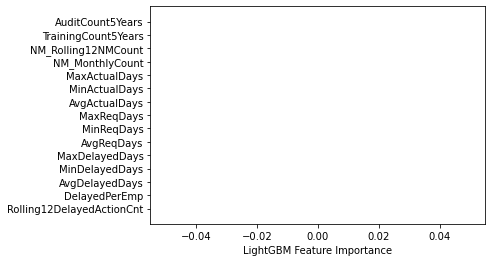

In [156]:
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("LightGBM Feature Importance")

### Hyperparameter Optimaztion

In [157]:
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
param_test ={
    'num_leaves': sp_randint(6, 50), 
    'min_child_samples': sp_randint(100, 500),
    'min_child_weight': [1e-5, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4],
    'subsample': sp_uniform(loc=0.2, scale=0.8),
    'colsample_bytree': sp_uniform(loc=0.4, scale=0.6),
    'reg_alpha': [0, 1e-1, 1, 2, 5, 7, 10, 50, 100],
    'reg_lambda': [0, 1e-1, 1, 5, 10, 20, 50, 100]
}

In [158]:
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)
model = LGBMRegressor()
lgb_grid = GridSearchCV(model, params, scoring="neg_mean_absolute_error", cv = cv, n_jobs = -1,verbose=False)

In [159]:
lgb_grid.fit(X, y)

GridSearchCV(cv=RepeatedKFold(n_repeats=10, n_splits=5, random_state=0),
             estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'gamma': [0.5, 1, 2], 'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 5, 10]},
             scoring='neg_mean_absolute_error', verbose=False)

In [160]:
print(lgb_grid.best_score_)
print(lgb_grid.best_params_)

-5.123304369121951
{'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 1}


### Feature Importance of The Best Estimator

In [161]:
lgb_grid.best_estimator_.feature_importances_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

This suggests that the lightGBM fails to achieve feature importance in this case.

## Catboost

### Import Libraries

In [162]:
#conda install -c conda-forge lightgbm
from catboost import CatBoostRegressor

### import model

In [163]:
model = CatBoostRegressor()

### cross-validation

In [164]:
start = time()
cv = RepeatedKFold(n_splits=5, n_repeats=50, random_state=0)
score = cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)

speed["CatBoost"] = np.round(time() - start, 3)
accuracy["CatBoost"] = np.nanmean(score).round(3)

print(
    f"Mean Accuracy: {accuracy['CatBoost']}\nStd: {np.std(score):.3f}\nRun time: {speed['CatBoost']}s"
)

Mean Accuracy: -2.119
Std: 1.677
Run time: 132.857s


In [165]:
#score

In [166]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': -1.459,
 'XGB': -1.581,
 'CatBoost': -2.119,
 'HistGradientBoosting': -5.122,
 'LGBM': -5.122}

In [167]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'LGBM': 1.583,
 'GradientBoosting': 3.78,
 'HistGradientBoosting': 5.728,
 'XGB': 6.869,
 'CatBoost': 132.857}

### fit the model 

In [168]:
# fit the model on the whole dataset
#model = CatBoostRegressor()
model.fit(X, y,verbose_eval=False)

### Plot Feature Importance

In [169]:
print("Feature Importance: ",model.feature_importances_)

Feature Importance:  [20.5678865  22.6333273   4.83569783  1.27829703 10.54951566  3.17974758
  1.31560452  8.12781023  8.12000687  4.14687287  2.39215217  1.95552907
  8.84347322  1.36616674  0.68791242]


Text(0.5, 0, 'CatBoostRegressor Feature Importance')

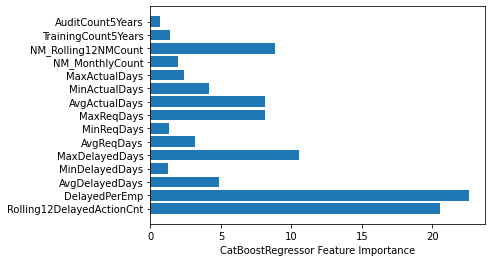

In [170]:
plt.barh(model.feature_names_, model.feature_importances_)
plt.xlabel("CatBoostRegressor Feature Importance")

In [171]:
sorted_idx = model.feature_importances_.argsort()
rank_cat_c_b = pd.DataFrame( (np.arange(1,len(model.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["CatBoost (Default)"])
rank_cat_c_b

,CatBoost (Default)
DelayedPerEmp,1
Rolling12DelayedActionCnt,2
MaxDelayedDays,3
NM_Rolling12NMCount,4
MaxReqDays,5
AvgActualDays,6
AvgDelayedDays,7
MinActualDays,8
AvgReqDays,9
MaxActualDays,10


In [172]:
#dir(model)

In [173]:
model.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'subsample': 1,
 'use_best_model': False,
 'random_seed': 0,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'learning_rate': 0.01848199963569641,
 'score_function': 'Cosine',
 'task_type': 'CPU',
 'leaf_estimation_iterations': 1,
 'bootstrap_type': 'MVS',
 'max_leaves': 64}

In [174]:
model.learning_rate_

0.01848199963569641

### Hyperparameter Optimaztion

In [175]:
parameters = {'depth'         : [6,8,10],
          'learning_rate' : [0.01, 0.02, 0.1],
          'iterations'    : [100, 500, 1000]
         }
model = CatBoostRegressor()
cat_grid = GridSearchCV(estimator=model, param_grid = parameters, scoring="neg_mean_absolute_error", cv = 5, n_jobs = -1,verbose=False)


In [176]:
cat_grid.fit(X, y)   

0:	learn: 5.5898992	total: 579us	remaining: 579ms
1:	learn: 5.5710423	total: 1.18ms	remaining: 589ms
2:	learn: 5.5490394	total: 1.52ms	remaining: 505ms
3:	learn: 5.5241129	total: 1.83ms	remaining: 457ms
4:	learn: 5.4972387	total: 2.3ms	remaining: 457ms
5:	learn: 5.4757961	total: 2.76ms	remaining: 457ms
6:	learn: 5.4570062	total: 3.21ms	remaining: 456ms
7:	learn: 5.4377315	total: 3.81ms	remaining: 472ms
8:	learn: 5.4173607	total: 3.97ms	remaining: 437ms
9:	learn: 5.3973785	total: 4.54ms	remaining: 449ms
10:	learn: 5.3725703	total: 4.93ms	remaining: 443ms
11:	learn: 5.3524792	total: 5.33ms	remaining: 439ms
12:	learn: 5.3278565	total: 5.65ms	remaining: 429ms
13:	learn: 5.3083612	total: 6.04ms	remaining: 425ms
14:	learn: 5.2904360	total: 6.37ms	remaining: 419ms
15:	learn: 5.2707947	total: 6.77ms	remaining: 416ms
16:	learn: 5.2477165	total: 7.02ms	remaining: 406ms
17:	learn: 5.2277349	total: 7.5ms	remaining: 409ms
18:	learn: 5.2029494	total: 7.82ms	remaining: 404ms
19:	learn: 5.1821680	tota

268:	learn: 2.0042626	total: 108ms	remaining: 294ms
269:	learn: 1.9967163	total: 109ms	remaining: 294ms
270:	learn: 1.9896083	total: 109ms	remaining: 294ms
271:	learn: 1.9797196	total: 110ms	remaining: 293ms
272:	learn: 1.9726174	total: 110ms	remaining: 293ms
273:	learn: 1.9676679	total: 111ms	remaining: 293ms
274:	learn: 1.9614771	total: 111ms	remaining: 294ms
275:	learn: 1.9512933	total: 112ms	remaining: 294ms
276:	learn: 1.9430884	total: 112ms	remaining: 293ms
277:	learn: 1.9363453	total: 113ms	remaining: 293ms
278:	learn: 1.9269352	total: 113ms	remaining: 293ms
279:	learn: 1.9192489	total: 114ms	remaining: 292ms
280:	learn: 1.9110132	total: 114ms	remaining: 291ms
281:	learn: 1.9047068	total: 114ms	remaining: 291ms
282:	learn: 1.8997277	total: 115ms	remaining: 291ms
283:	learn: 1.8930007	total: 115ms	remaining: 291ms
284:	learn: 1.8850996	total: 116ms	remaining: 290ms
285:	learn: 1.8777864	total: 116ms	remaining: 290ms
286:	learn: 1.8717229	total: 117ms	remaining: 290ms
287:	learn: 

494:	learn: 0.9030153	total: 224ms	remaining: 229ms
495:	learn: 0.9007592	total: 225ms	remaining: 229ms
496:	learn: 0.8966104	total: 226ms	remaining: 228ms
497:	learn: 0.8937243	total: 226ms	remaining: 228ms
498:	learn: 0.8907998	total: 227ms	remaining: 228ms
499:	learn: 0.8865561	total: 227ms	remaining: 227ms
500:	learn: 0.8831837	total: 228ms	remaining: 227ms
501:	learn: 0.8791280	total: 228ms	remaining: 226ms
502:	learn: 0.8769160	total: 229ms	remaining: 226ms
503:	learn: 0.8730040	total: 230ms	remaining: 226ms
504:	learn: 0.8708649	total: 230ms	remaining: 226ms
505:	learn: 0.8687313	total: 231ms	remaining: 226ms
506:	learn: 0.8665736	total: 232ms	remaining: 226ms
507:	learn: 0.8643156	total: 233ms	remaining: 225ms
508:	learn: 0.8621629	total: 234ms	remaining: 225ms
509:	learn: 0.8600837	total: 234ms	remaining: 225ms
510:	learn: 0.8573710	total: 235ms	remaining: 225ms
511:	learn: 0.8543863	total: 236ms	remaining: 225ms
512:	learn: 0.8504814	total: 236ms	remaining: 224ms
513:	learn: 

722:	learn: 0.4445919	total: 346ms	remaining: 133ms
723:	learn: 0.4434597	total: 346ms	remaining: 132ms
724:	learn: 0.4423232	total: 347ms	remaining: 132ms
725:	learn: 0.4407740	total: 347ms	remaining: 131ms
726:	learn: 0.4396610	total: 348ms	remaining: 131ms
727:	learn: 0.4385505	total: 349ms	remaining: 130ms
728:	learn: 0.4370153	total: 349ms	remaining: 130ms
729:	learn: 0.4359135	total: 350ms	remaining: 129ms
730:	learn: 0.4343863	total: 350ms	remaining: 129ms
731:	learn: 0.4323942	total: 351ms	remaining: 128ms
732:	learn: 0.4312893	total: 351ms	remaining: 128ms
733:	learn: 0.4301853	total: 352ms	remaining: 127ms
734:	learn: 0.4290988	total: 352ms	remaining: 127ms
735:	learn: 0.4279823	total: 353ms	remaining: 126ms
736:	learn: 0.4269016	total: 353ms	remaining: 126ms
737:	learn: 0.4254090	total: 354ms	remaining: 126ms
738:	learn: 0.4239337	total: 355ms	remaining: 125ms
739:	learn: 0.4228638	total: 355ms	remaining: 125ms
740:	learn: 0.4217962	total: 356ms	remaining: 124ms
741:	learn: 

970:	learn: 0.2342575	total: 474ms	remaining: 14.2ms
971:	learn: 0.2336747	total: 475ms	remaining: 13.7ms
972:	learn: 0.2330934	total: 476ms	remaining: 13.2ms
973:	learn: 0.2325135	total: 476ms	remaining: 12.7ms
974:	learn: 0.2319352	total: 477ms	remaining: 12.2ms
975:	learn: 0.2313583	total: 477ms	remaining: 11.7ms
976:	learn: 0.2307829	total: 478ms	remaining: 11.3ms
977:	learn: 0.2302090	total: 479ms	remaining: 10.8ms
978:	learn: 0.2296366	total: 480ms	remaining: 10.3ms
979:	learn: 0.2290656	total: 481ms	remaining: 9.81ms
980:	learn: 0.2284961	total: 481ms	remaining: 9.32ms
981:	learn: 0.2279281	total: 482ms	remaining: 8.83ms
982:	learn: 0.2273615	total: 482ms	remaining: 8.34ms
983:	learn: 0.2267963	total: 483ms	remaining: 7.85ms
984:	learn: 0.2262327	total: 483ms	remaining: 7.36ms
985:	learn: 0.2256704	total: 484ms	remaining: 6.87ms
986:	learn: 0.2251096	total: 485ms	remaining: 6.38ms
987:	learn: 0.2245505	total: 485ms	remaining: 5.89ms
988:	learn: 0.2239925	total: 486ms	remaining: 

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x000000000D445520>,
             n_jobs=-1,
             param_grid={'depth': [6, 8, 10], 'iterations': [100, 500, 1000],
                         'learning_rate': [0.01, 0.02, 0.1]},
             scoring='neg_mean_absolute_error', verbose=False)

In [177]:
print(cat_grid.best_score_)
print(cat_grid.best_params_)

-4.194920093013392
{'depth': 6, 'iterations': 1000, 'learning_rate': 0.01}


In [178]:
#cat_grid.best_estimator_.get_feature_importance()

In [179]:
#plt.barh(cat_grid.best_estimator_.feature_names_, cat_grid.best_estimator_.get_feature_importance())
#plt.xlabel("CatBoostRegressor Feature Importance")

### Fit the final model

In [180]:
cat_grid.best_params_

{'depth': 6, 'iterations': 1000, 'learning_rate': 0.01}

In [181]:
cbc_final = CatBoostRegressor(**model.get_params())

In [182]:
#set optimal parameters
cbc_final.set_params(**cat_grid.best_params_)

In [183]:
#fit on the whole dataset
cbc_final.fit(X, y,verbose_eval=False)

In [184]:
cbc_final.feature_importances_

array([23.14162881, 19.73935288,  4.53083662,  0.99795544, 10.97748201,
        3.68741119,  3.2794091 ,  8.47629551,  6.31178563,  5.89638962,
        3.33193311,  1.52601635,  5.93765284,  1.4549922 ,  0.71085868])

Text(0.5, 0, 'CatBoostRegressor Feature Importance')

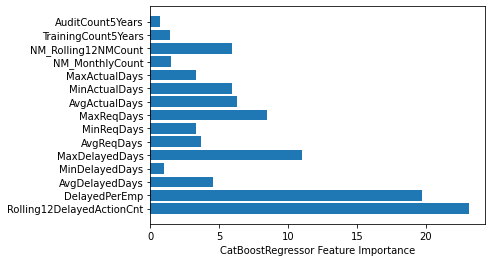

In [185]:
plt.barh(cbc_final.feature_names_, cbc_final.feature_importances_)
plt.xlabel("CatBoostRegressor Feature Importance")

In [186]:
sorted_idx = cbc_final.feature_importances_.argsort()
rank_cat_c_o = pd.DataFrame( (np.arange(1,len(cbc_final.feature_importances_[sorted_idx])+1,1)),index=X.columns[sorted_idx][::-1], columns=["CatBoost (Optimised)"])
change =pd.DataFrame( rank_cat_c_b["CatBoost (Default)"]-rank_cat_c_o["CatBoost (Optimised)"], columns=["ranking change"])
ranking_ = pd.concat([rank_cat_c_o, rank_cat_c_b, change], axis=1)
ranking_

,CatBoost (Optimised),CatBoost (Default),ranking change
Rolling12DelayedActionCnt,1,2,1
DelayedPerEmp,2,1,-1
MaxDelayedDays,3,3,0
MaxReqDays,4,5,1
AvgActualDays,5,6,1
NM_Rolling12NMCount,6,4,-2
MinActualDays,7,8,1
AvgDelayedDays,8,7,-1
AvgReqDays,9,9,0
MaxActualDays,10,10,0


Similarly to the CatBoost implementation in the classification problem, the hyperparameters slightly affect the ranking of the feature importance within the given hyperparameter searching space.
Compared to the number of features selected by the XGboost, CatBoost selects much more feature than the XGBoost.
In terms of values of feature importance, primary features selected by the CatBoost are not as dominate as the XGboost does to other features, suggesting its different construction of the model from the XGBoost's.

In [187]:
rank_c = pd.concat([rank_c, rank_cat_c_o], axis=1)

In [188]:
rank_c

,GradientBoosting,XGBoost (Optimised),CatBoost (Optimised)
Rolling12DelayedActionCnt,1,1.0,1
DelayedPerEmp,2,NaN,2
AvgReqDays,3,3.0,9
NM_Rolling12NMCount,4,5.0,6
AvgActualDays,5,6.0,5
AvgDelayedDays,6,2.0,8
MinActualDays,7,NaN,7
MinReqDays,8,NaN,11
MaxDelayedDays,9,NaN,3
NM_MonthlyCount,10,NaN,12


In [189]:
#save the ranking file
rank_c.index.name = "Features"
rank_c.to_csv('result/Feature_importance_ranking_regressor.csv')

## Section Summary 

TThis section investigates implementations for a safety regression problem.
Five implementations included are GradientBoosting,Histogram-based Gradient Boosting, XGBoost, LightGBM and CatBoost.
These implementations reach a decent accuracy when they trained models by a safety dataset.
Three implementations, GradientBoosting, XGB, and CatBoost, also produce feature importances with the models produced.
The rankings of feature importances suggest that the ``Rolling12DelayedActionCnt``is the most important feature for the construction of the models.
Although the definitions of feature importance differ among this investigation and the previous one, their ranking results are relatively consistent, suggesting feature importance can be considered as a critical factor for safety prediction.

This section also conducts hyperparameter-tuning for XGBoost algorithm implementations: XGBoost, LightGBM and CatBoost.
Models with tuned hyperparameters have better performances than their default models.
As hyperparameters impact the construction of a model, the hyperparameter-tuning process is preferred for a better performance of the model when it faces a complex dataset.

In [190]:
rank_c

,GradientBoosting,XGBoost (Optimised),CatBoost (Optimised)
Features,,,
Rolling12DelayedActionCnt,1,1.0,1
DelayedPerEmp,2,NaN,2
AvgReqDays,3,3.0,9
NM_Rolling12NMCount,4,5.0,6
AvgActualDays,5,6.0,5
AvgDelayedDays,6,2.0,8
MinActualDays,7,NaN,7
MinReqDays,8,NaN,11
MaxDelayedDays,9,NaN,3


In [191]:
print("Accuracy:")
{k: v for k, v in sorted(accuracy.items(), key=lambda i: i[1], reverse=True)}

Accuracy:


{'GradientBoosting': -1.459,
 'XGB': -1.581,
 'CatBoost': -2.119,
 'HistGradientBoosting': -5.122,
 'LGBM': -5.122}

In [192]:
print("Speed:")
{k: v for k, v in sorted(speed.items(), key=lambda i: i[1], reverse=False)}

Speed:


{'LGBM': 1.583,
 'GradientBoosting': 3.78,
 'HistGradientBoosting': 5.728,
 'XGB': 6.869,
 'CatBoost': 132.857}